# Single Cell RNASeq Data Files' Exploration and Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install scanpy anndata scipy scrublet

In [ ]:
import os
import gc

import scanpy as sc
import anndata as ad

import scrublet as scr

import pandas as pd
import numpy as np

from scipy import sparse

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [ ]:
sc.settings.verbosity = 3
sc.set_figure_params(figsize=(6, 6))

In [ ]:
CONFIG = {
    "base_path": "/content/drive/...",
    "donor": "donor4",
    "file": "Wound30_donor4_matrix.h5"}

full_path = os.path.join(CONFIG["base_path"], CONFIG["donor"], CONFIG["file"])

### Load data

In [ ]:
adata = sc.read_10x_h5(full_path)

In [ ]:
adata.var_names_make_unique()

In [ ]:
adata

In [ ]:
adata.shape

### Observation-level Annotations

In [ ]:
adata.obs["donor_id"] = "D4"
adata.obs["healing_stage"] = "wound30"

### Healing State Encoding

A binary label was defined where control skin samples are assigned class 0, and all wound healing stages (day 1, 7, 30) are grouped as class 1 to capture the overall activation of the wound healing program.

In [ ]:
adata.obs["healing_state"] = (adata.obs["healing_stage"] != "skin").astype(int)

In [ ]:
adata.obs.head()

In [ ]:
adata.var.head()

### Sparcity Check

In [ ]:
print(f"Matrix type: {type(adata.X)}")

if sparse.issparse(adata.X):
    print(f"Sparsity: {100 * (1 - adata.X.nnz / (adata.n_obs * adata.n_vars)):.2f}%")

Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Sparsity: 96.41%


### Sparcity Distribution

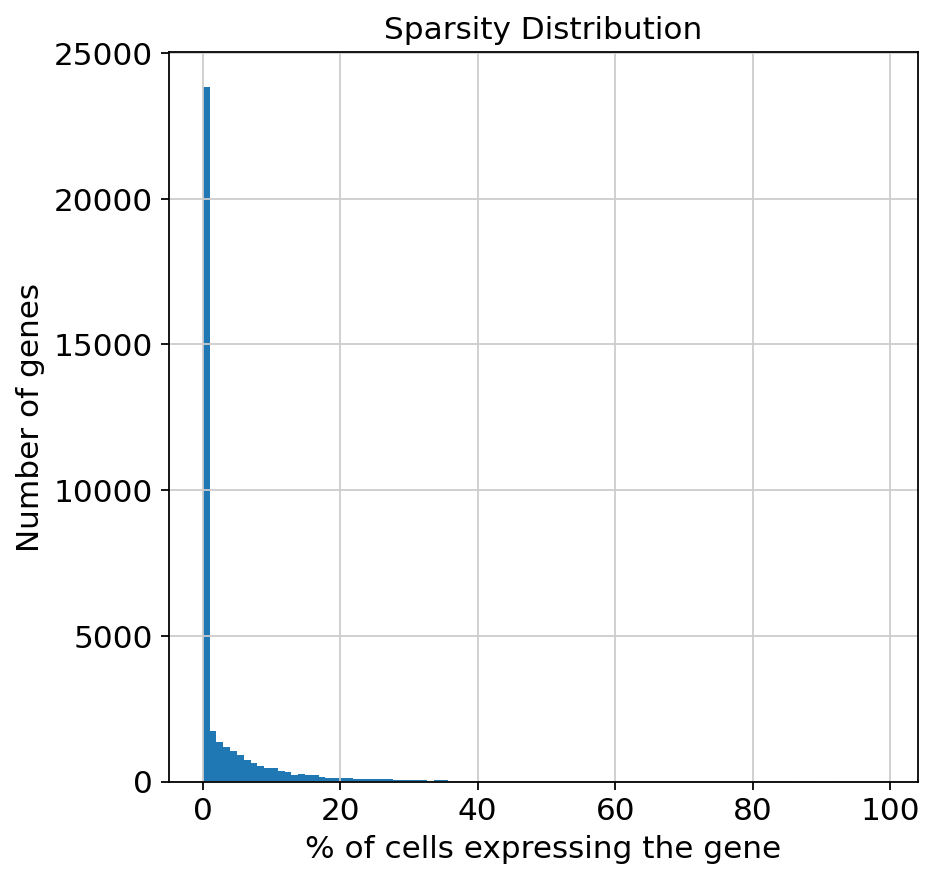

In [ ]:
n_cells_excl_zeros = np.sum(adata.X > 0, axis=0)
if isinstance(n_cells_excl_zeros, np.matrix):
    n_cells_excl_zeros = n_cells_excl_zeros.A1

genes_detected_pct = (n_cells_excl_zeros / adata.n_obs) * 100

plt.hist(genes_detected_pct, bins=100)
plt.xlabel('% of cells expressing the gene')
plt.ylabel('Number of genes')
plt.title('Sparsity Distribution')
plt.show()

### Highest expressed genes

normalizing counts per cell
    finished (0:00:00)


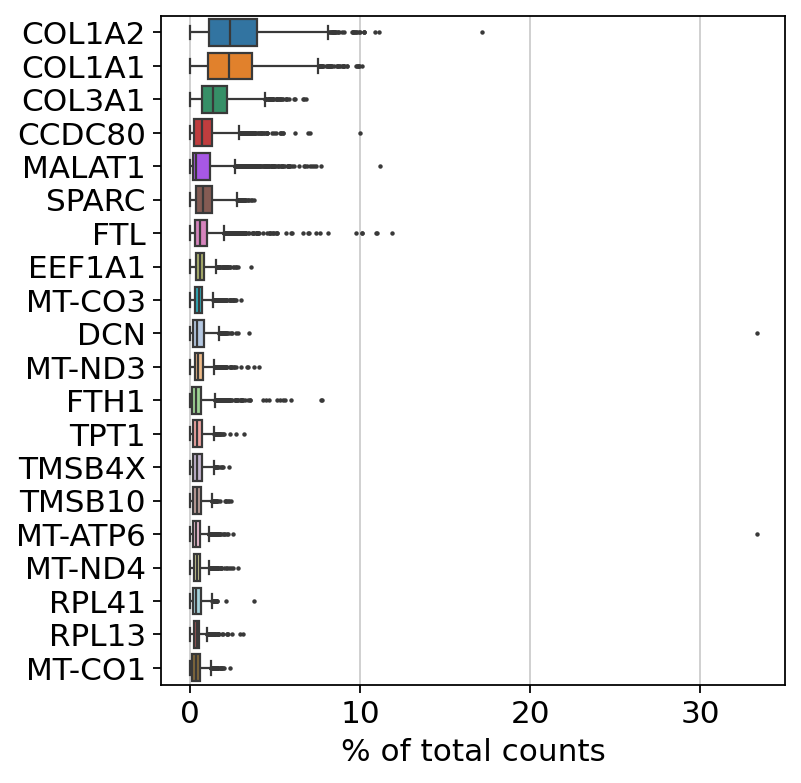

In [ ]:
sc.pl.highest_expr_genes(adata, n_top=20)

### Mitochondrial Gene Annotation

Mitochondrial gene expression is a QC indicator. High mitochondrial activity may reflect damaged tissue spots.

In [ ]:
adata.var[adata.var.index.str.startswith('MT-')]

In [ ]:
adata.var["MT"] = adata.var_names.str.startswith("MT-")

In [ ]:
adata.var

### Quality Control

In [ ]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["MT"], inplace=True)

In [ ]:
adata.var

,gene_ids,feature_types,genome,MT,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,False,0,0.000000,0.000000,100.000000,0.0,0.000000
FAM138A,ENSG00000237613,Gene Expression,GRCh38,False,0,0.000000,0.000000,100.000000,0.0,0.000000
OR4F5,ENSG00000186092,Gene Expression,GRCh38,False,0,0.000000,0.000000,100.000000,0.0,0.000000
RP11-34P13.7,ENSG00000238009,Gene Expression,GRCh38,False,7,0.003507,0.003501,99.649299,7.0,2.079442
RP11-34P13.8,ENSG00000239945,Gene Expression,GRCh38,False,0,0.000000,0.000000,100.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
ENSG00000277836,ENSG00000277836,Gene Expression,GRCh38,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSG00000278633,ENSG00000278633,Gene Expression,GRCh38,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSG00000276017,ENSG00000276017,Gene Expression,GRCh38,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSG00000278817,ENSG00000278817,Gene Expression,GRCh38,False,73,0.041082,0.040261,96.342685,82.0,4.418840


In [ ]:
adata.obs

,donor_id,healing_stage,healing_state,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT
AAACAGAGCGACTCCT-1,D4,wound30,1,309,5.736572,381.0,5.945421,32.020997,45.144357,71.391076,100.000000,14.0,2.708050,3.674541
AAACCGTTCGTCCAGG-1,D4,wound30,1,1107,7.010312,2222.0,7.706613,34.788479,43.384338,54.320432,72.682268,33.0,3.526361,1.485149
AAACGAGACGGTTGAT-1,D4,wound30,1,1980,7.591357,4395.0,8.388451,23.367463,35.676906,47.076223,63.458476,200.0,5.303305,4.550626
AAACGGTTGCGAACTG-1,D4,wound30,1,274,5.616771,370.0,5.916202,39.459459,52.972973,80.000000,100.000000,19.0,2.995732,5.135135
AAACTCGGTTCGCAAT-1,D4,wound30,1,386,5.958425,566.0,6.340359,34.098940,49.469965,67.137809,100.000000,47.0,3.871201,8.303886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTGTTTCCCGAAAG-1,D4,wound30,1,1200,7.090910,2329.0,7.753623,31.816230,40.704165,51.223701,69.944182,55.0,4.025352,2.361529
TTGTTAGCAAATTCGA-1,D4,wound30,1,2177,7.686162,5980.0,8.696343,38.561873,46.170569,54.615385,68.093645,198.0,5.293305,3.311037
TTGTTCAGTGTGCTAC-1,D4,wound30,1,2046,7.624131,4754.0,8.466952,31.342028,39.882204,49.600337,64.682373,124.0,4.828314,2.608330
TTGTTGTGTGTCAAGA-1,D4,wound30,1,352,5.866468,459.0,6.131227,32.461874,45.098039,66.884532,100.000000,14.0,2.708050,3.050109


In [ ]:
adata.obs.sort_values('total_counts')

,donor_id,healing_stage,healing_state,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT
TCGTGTACTATGGATG-1,D4,wound30,1,3,1.386294,3.0,1.386294,100.000000,100.000000,100.000000,100.000000,1.0,0.693147,33.333336
AGAAGAGCGCCGTTCC-1,D4,wound30,1,10,2.397895,10.0,2.397895,100.000000,100.000000,100.000000,100.000000,0.0,0.000000,0.000000
CGTTGAATACCGCGCT-1,D4,wound30,1,31,3.465736,32.0,3.496508,100.000000,100.000000,100.000000,100.000000,0.0,0.000000,0.000000
GAACAGATTACTAAAT-1,D4,wound30,1,33,3.526361,35.0,3.583519,100.000000,100.000000,100.000000,100.000000,0.0,0.000000,0.000000
CCGCGTAGGTAAGGGC-1,D4,wound30,1,42,3.761200,45.0,3.828641,100.000000,100.000000,100.000000,100.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GATAAATCGGTGGATG-1,D4,wound30,1,5423,8.598589,22715.0,10.030825,27.836232,38.525204,49.011666,60.338983,856.0,6.753438,3.768435
GAGTACGGGTATACAA-1,D4,wound30,1,5467,8.606668,22784.0,10.033857,27.119909,37.377107,47.910815,59.585674,779.0,6.659294,3.419066
CAGTGTCCGCAGAATG-1,D4,wound30,1,5498,8.612322,23501.0,10.064840,27.377558,38.832390,49.687247,60.912302,945.0,6.852242,4.021106
AACAGGAAATCGAATA-1,D4,wound30,1,5875,8.678632,28829.0,10.269172,29.283014,42.041000,52.381283,63.113532,1343.0,7.203405,4.658504


### Distribution Visualizations

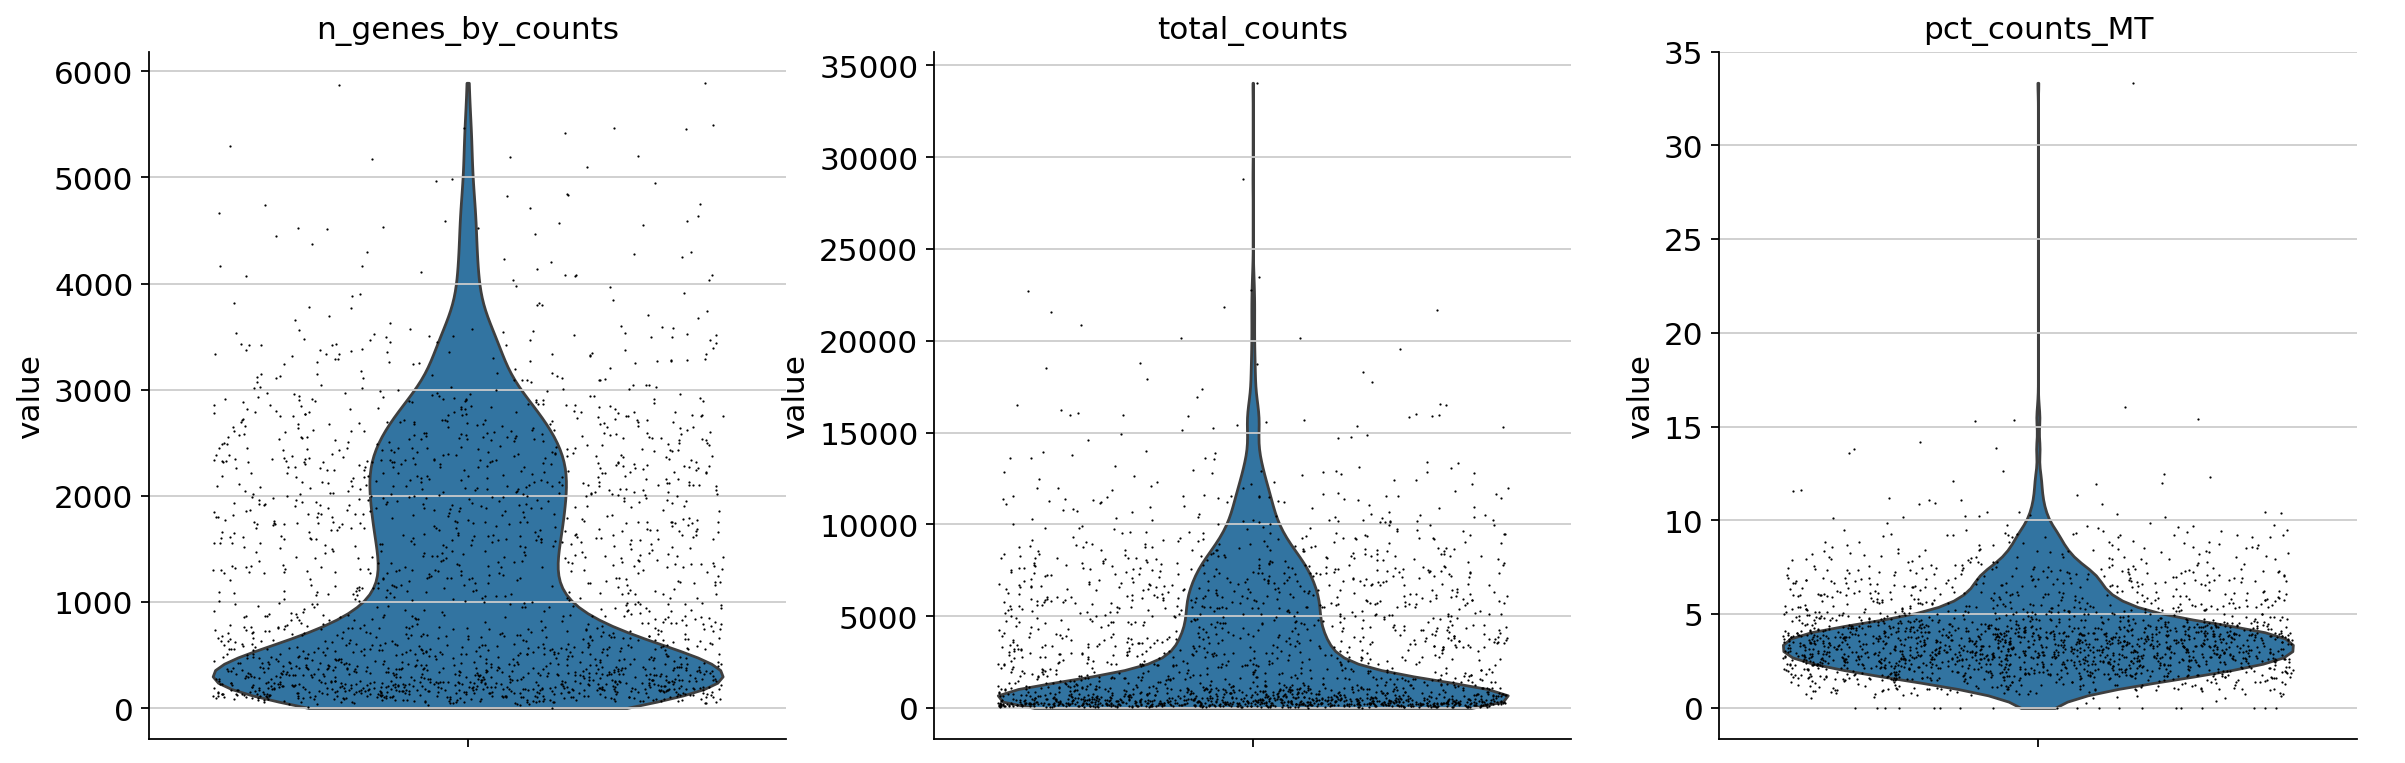

In [ ]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_MT"],
    jitter=0.4,
    multi_panel=True
)

**Interpretation:**


- `n_genes_by_counts`

The distribution of detected genes per cell shows that most cells contain 300–1500 detected genes, a biologically meaningful transcriptional signal across the majority of the dataset. A long upper tail extending to approximately 7000–8000 genes was observed. These high-gene cells may represent either highly transcriptionally active biological populations or potential doublets/multiplets.

- `total_counts`

The total UMI/count distribution shows that most cells contain fewer than 5000 counts, while a smaller subset extends to much higher values. This indicates heterogeneous sequencing depth across cells, which is expected in wound and skin-related tissue samples.

- `pct_counts_MT`

The mitochondrial percentage distribution is centered around 5–7%, with most cells remaining below 10%.  Overall, the dataset does not show severe mitochondrial contamination. Considering the biological context of wound-healing and skin tissue, a moderate mitochondrial threshold was preferred to avoid removing biologically relevant stressed populations.


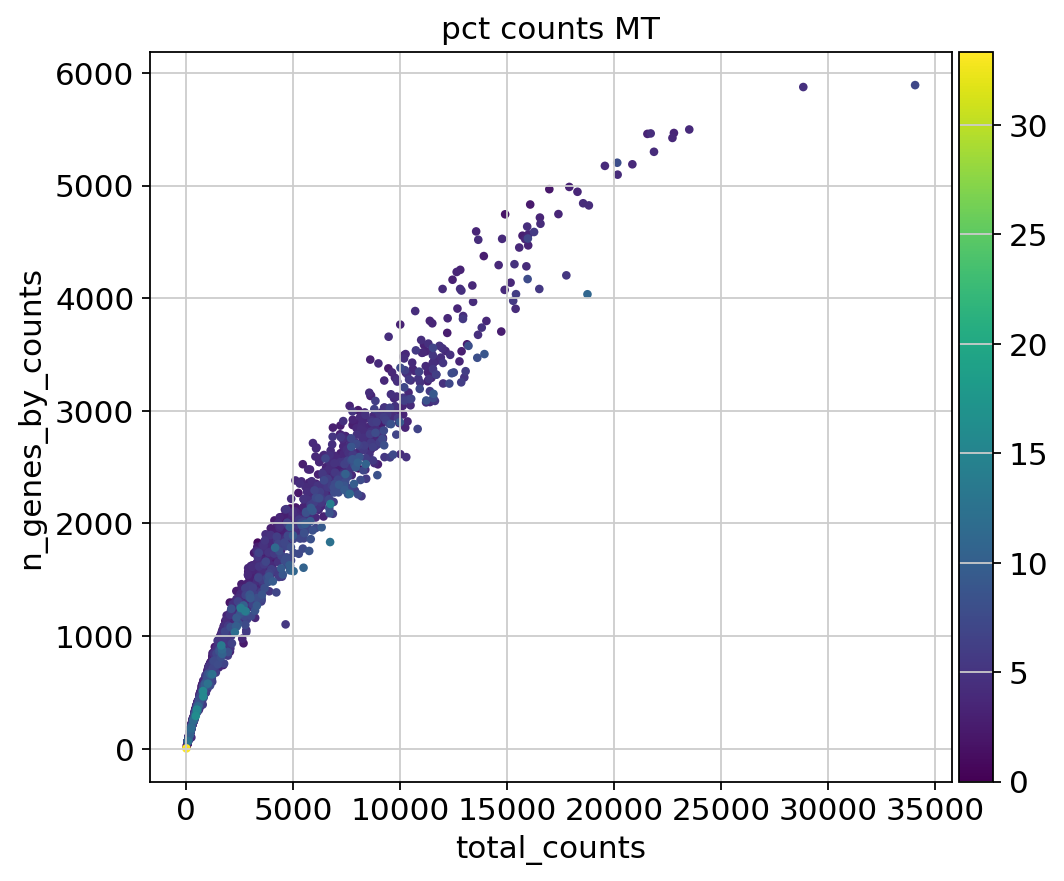

In [ ]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_MT"
)

**Interpretation**


The scatter plot of total counts versus detected genes shows a smooth positive relationship.

High-count cells continue to follow the same biological trend, which suggests that not all high-count cells are technical artifacts or doublets.

This scatter tells that the data does not suffer from high ambient RNA contamination (which would show up as points stretching out far to the right with very low gene counts).

### Data-Driven Filtering

Cell filtering

In [ ]:
adata = adata[adata.obs["n_genes_by_counts"] >= 200].copy()
adata = adata[adata.obs["total_counts"] >= 1000].copy()

In [ ]:
adata = adata[adata.obs["n_genes_by_counts"] < 4000].copy()
adata = adata[adata.obs["total_counts"] < 15000].copy()

In [ ]:
adata = adata[adata.obs["pct_counts_MT"] < 10].copy()

Upper Quantile filtering

In [ ]:
upper_gene_limit = np.quantile(adata.obs["n_genes_by_counts"],0.995)
adata = adata[adata.obs["n_genes_by_counts"] < upper_gene_limit].copy()

### Doublet Detection

In [ ]:
scrub = scr.Scrublet(adata.X, expected_doublet_rate=0.06)

doublet_scores, predicted_doublets = scrub.scrub_doublets()

adata.obs["doublet_score"] = doublet_scores
adata.obs["predicted_doublet"] = predicted_doublets

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.41
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 4.9%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 11.2%
Elapsed time: 0.7 seconds


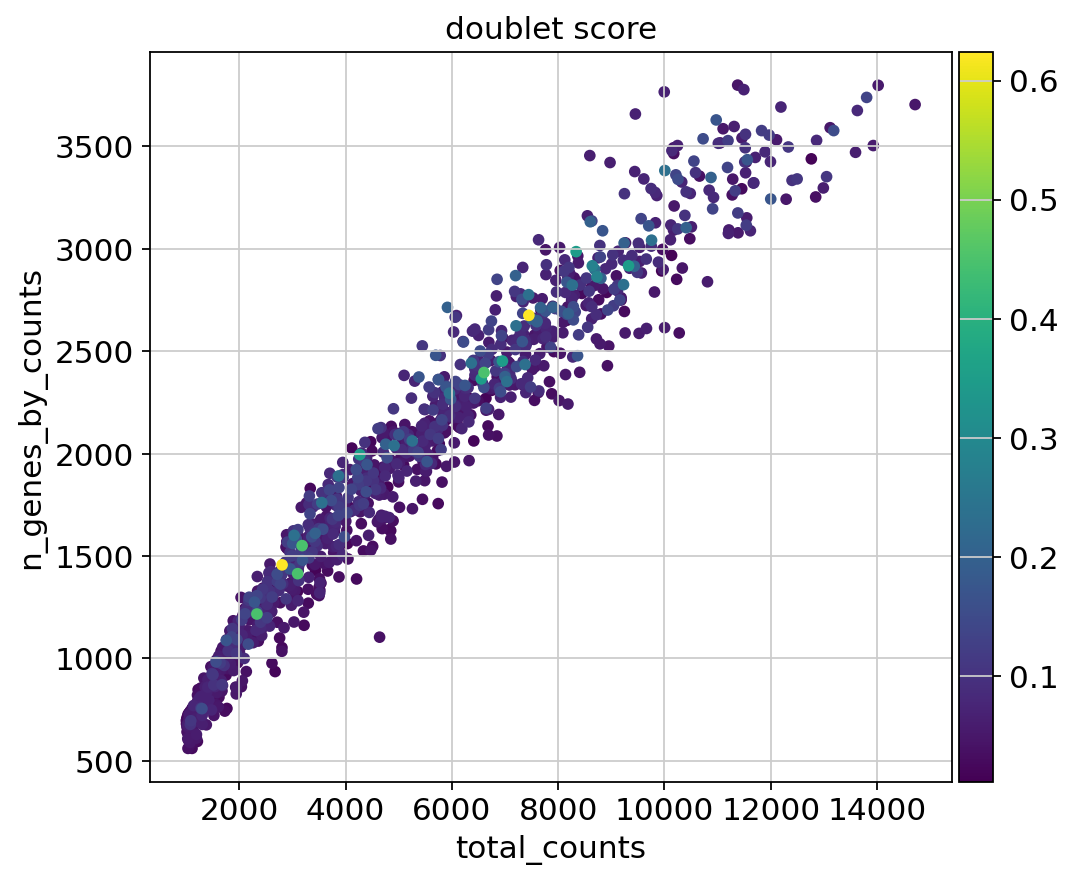

In [ ]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="doublet_score"
)

In [ ]:
adata.obs["predicted_doublet"].value_counts()

,count
predicted_doublet,
False,1085
True,6


In [ ]:
adata = adata[~adata.obs["predicted_doublet"]].copy()

**Interpretation**

Doublet detection identified only 3 predicted doublets out of 958 total cells.
Given the minimal detected contamination, only the computationally predicted doublets were removed.

Most cells exhibited low doublet scores, this suggests that the majority of highly expressed cells represent genuine biological variabilitys.



Gene filtering

In [ ]:
sc.pp.filter_genes(adata, min_cells=3)

filtered out 20224 genes that are detected in less than 3 cells


In [ ]:
sc.pp.calculate_qc_metrics(adata,qc_vars=["MT"], inplace=True)

In [ ]:
adata.var

,gene_ids,feature_types,genome,MT,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
RP11-34P13.7,ENSG00000238009,Gene Expression,GRCh38,False,6,0.005530,0.005515,99.447005,6.0,1.945910,6
RP11-34P13.13,ENSG00000241860,Gene Expression,GRCh38,False,3,0.002765,0.002761,99.723502,3.0,1.386294,3
LINC01409,ENSG00000237491,Gene Expression,GRCh38,False,26,0.024885,0.024580,97.603687,27.0,3.332205,26
LINC01128,ENSG00000228794,Gene Expression,GRCh38,False,40,0.039631,0.038866,96.313364,43.0,3.784190,40
FAM41C,ENSG00000230368,Gene Expression,GRCh38,False,10,0.009217,0.009174,99.078341,10.0,2.397895,10
...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000273748,ENSG00000273748,Gene Expression,GRCh38,False,15,0.017512,0.017360,98.617512,19.0,2.995732,15
ENSG00000271254,ENSG00000271254,Gene Expression,GRCh38,False,49,0.047005,0.045933,95.483871,51.0,3.951244,49
ENSG00000276345,ENSG00000276345,Gene Expression,GRCh38,False,72,0.073733,0.071141,93.364055,80.0,4.394449,72
ENSG00000278817,ENSG00000278817,Gene Expression,GRCh38,False,54,0.056221,0.054698,95.023041,61.0,4.127134,54


In [ ]:
adata.obs

,donor_id,healing_stage,healing_state,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT,doublet_score,predicted_doublet
AAACCGTTCGTCCAGG-1,D4,wound30,1,1106,7.009409,2221.0,7.706163,34.804142,43.403872,54.344890,72.714993,33.0,3.526361,1.485817,0.027706,False
AAACGAGACGGTTGAT-1,D4,wound30,1,1976,7.589336,4391.0,8.387540,23.388750,35.709406,47.119107,63.516283,200.0,5.303305,4.554771,0.063306,False
AAAGGCTCTCGCGCCG-1,D4,wound30,1,933,6.839476,2128.0,7.663408,34.492481,47.227444,60.479323,79.652256,140.0,4.948760,6.578948,0.039964,False
AAAGGGATGTAGCAAG-1,D4,wound30,1,2324,7.751475,5889.0,8.681011,33.655969,41.365257,50.416030,64.306334,139.0,4.941642,2.360333,0.173367,False
AAAGGGCAGCTTGAAT-1,D4,wound30,1,688,6.535241,1082.0,6.987490,30.406654,41.866913,54.898336,82.624769,50.0,3.931826,4.621072,0.063306,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTGTATGCCACCAA-1,D4,wound30,1,1305,7.174724,3499.0,8.160519,34.695627,49.271220,61.531866,76.993427,218.0,5.389072,6.230352,0.037132,False
TTGTGTTTCCCGAAAG-1,D4,wound30,1,1197,7.088409,2326.0,7.752335,31.857266,40.756664,51.289768,70.034394,55.0,4.025352,2.364574,0.046377,False
TTGTTAGCAAATTCGA-1,D4,wound30,1,2170,7.682943,5973.0,8.695172,38.607065,46.224678,54.679391,68.173447,198.0,5.293305,3.314917,0.023884,False
TTGTTCAGTGTGCTAC-1,D4,wound30,1,2044,7.623153,4752.0,8.466532,31.355219,39.898990,49.621212,64.709596,124.0,4.828314,2.609428,0.200000,False


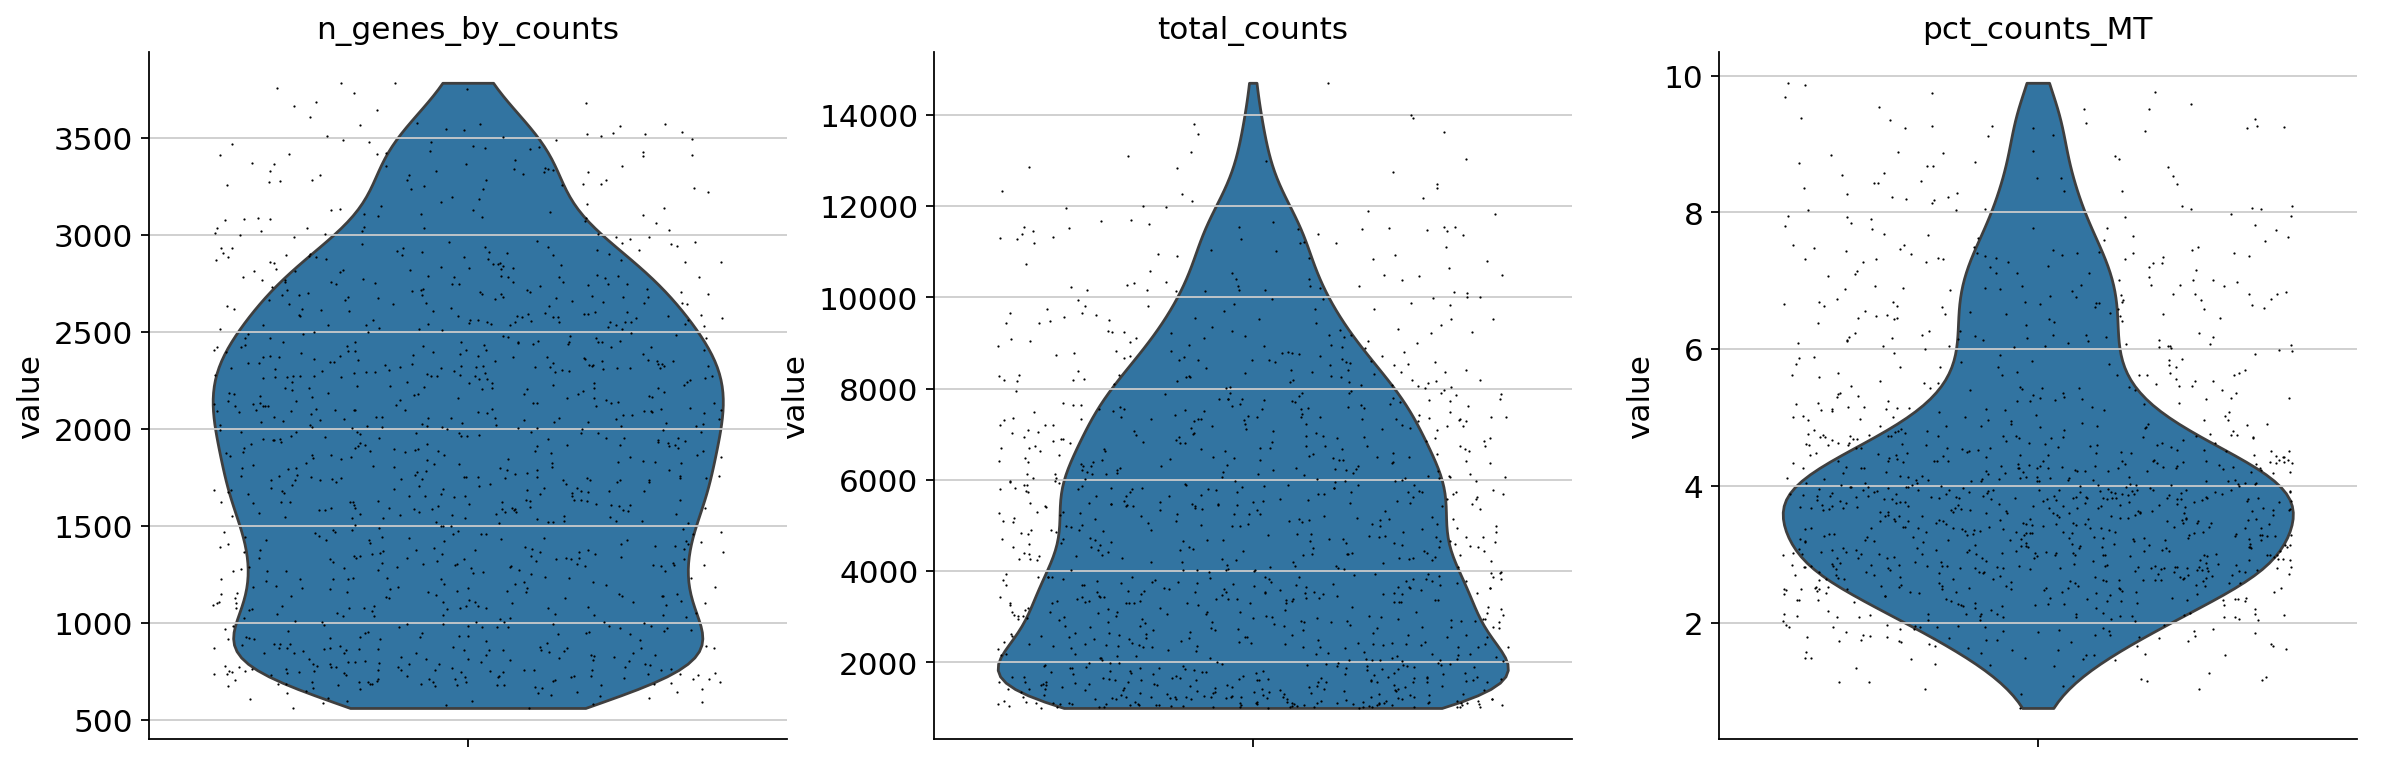

In [ ]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_MT"],
    jitter=0.4,
    multi_panel=True
)

In [ ]:
adata.shape

(1085, 16376)

### Save Filtered File

In [ ]:
adata.write("/content/drive/.../filtered_data/filtered_wound30_donor4_data.h5ad")

In [ ]:
print(os.path.exists("/content/drive/.../filtered_wound30_donor4_data.h5ad"))